# 🎮 Notebook 01 — The Game of Life: Agents, Environments, and MDPs

**Series**: RL Notebook Series · Act I — Mathematical Foundations · Post 1 of 15

---

## What You'll Learn

Every RL system, from a Roomba to AlphaGo, has the same skeleton:

> An **agent** takes **actions** in an **environment**, receives **rewards**, and learns a **policy** — a strategy for choosing actions.

In this notebook, you'll:
1. Build an environment (GridEnvironment) **from scratch**
2. Build an agent that acts randomly and measure how it does
3. Build a better agent with a hand-coded policy and see the difference
4. Formalise everything into the language of **Markov Decision Processes (MDPs)**

By the end, you'll have the vocabulary and the intuition to understand every RL paper's "problem setup" section.

## 1. The Agent-Environment Loop

Imagine teaching a dog to sit. The loop goes like this:

```
Dog (agent) observes: you hold a treat up (state)
Dog picks an action: sits down
You (environment) respond: give the treat (reward) + a new situation (next state)
Repeat.
```

In RL, **every problem** has this shape:

```
┌────────┐   action    ┌─────────────┐
│  Agent │ ──────────> │ Environment │
│        │ <────────── │             │
└────────┘  state,     └─────────────┘
            reward
```

Let's make this concrete by building a GridEnvironment.

In [13]:
# Standard imports we'll use throughout
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Make plots inline and pretty
%matplotlib inline
plt.rcParams.update({'figure.figsize': (8, 5), 'axes.grid': True, 'grid.alpha': 0.3})

# Set seed for reproducibility
np.random.seed(42)

## 2. Building a GridEnvironment from Scratch

Our world is a 4×4 grid. The agent starts in the top-left corner and wants to reach the bottom-right corner (the goal). Some cells are traps.

```
 S  .  .  .
 .  ■  .  X
 .  .  .  .
 X  .  .  G
```

- **S** = Start (0,0)
- **G** = Goal (3,3) → reward +1.0
- **■** = Wall (impassable)
- **X** = Trap → reward -1.0
- **·** = Empty → reward -0.1 (small penalty to encourage moving)

The agent has 4 actions: `0=UP, 1=RIGHT, 2=DOWN, 3=LEFT`.

### The Environment Implementation

In [14]:
class GridEnvironment:
    """
    A minimal GridEnvironment you build yourself.
    
    State: (row, col) tuple
    Actions: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
    """
    
    # Action effects: maps action_id -> (delta_row, delta_col)
    ACTION_DELTAS = {
        0: (-1, 0),  # UP
        1: (0, 1),   # RIGHT
        2: (1, 0),   # DOWN
        3: (0, -1),  # LEFT
    }
    ACTION_NAMES = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    
    def __init__(self, rows=4, cols=4):
        self.rows = rows
        self.cols = cols
        self.start = (0, 0)
        self.goal = (3, 3)
        self.walls = {(1, 1)}
        self.traps = {(1, 3), (3, 0)}
        
        # Rewards
        self.goal_reward = 1.0
        self.trap_reward = -1.0
        self.step_reward = -0.1  # small penalty per step
        
        # Current position
        self.agent_pos = self.start
    
    def reset(self):
        """Reset the agent to the start position. Returns the starting state."""
        self.agent_pos = self.start
        return self.agent_pos
    
    def step(self, action):
        """
        Execute one action. Returns (next_state, reward, done, info).
        
        Rules:
        1. Compute the intended next position using ACTION_DELTAS
        2. If next position is out of bounds OR a wall -> stay in place
        3. Otherwise, move to next position
        4. Check if new position is the goal or a trap to determine reward and done
        """
        # Step 1: Get the delta for this action
        dr, dc = self.ACTION_DELTAS[action]
        
        # Step 2: Compute intended new position
        new_row = self.agent_pos[0] + dr
        new_col = self.agent_pos[1] + dc
        
        # Step 3: Check if valid — stay in place if out of bounds or wall
        if (new_row < 0 or new_row >= self.rows or 
            new_col < 0 or new_col >= self.cols or
            (new_row, new_col) in self.walls):
            new_row, new_col = self.agent_pos  # Stay in place
        
        # Step 4: Update position
        self.agent_pos = (new_row, new_col)
        
        # Step 5: Determine reward and done
        if self.agent_pos == self.goal:
            return self.agent_pos, self.goal_reward, True, {}
        elif self.agent_pos in self.traps:
            return self.agent_pos, self.trap_reward, True, {}
        else:
            return self.agent_pos, self.step_reward, False, {}
    
    def render(self):
        """Pretty-print the grid with the agent's current position."""
        symbols = []
        for r in range(self.rows):
            row = []
            for c in range(self.cols):
                if (r, c) == self.agent_pos:
                    row.append(' 🤖')
                elif (r, c) == self.goal:
                    row.append(' 🏆')
                elif (r, c) in self.walls:
                    row.append(' 🧱')
                elif (r, c) in self.traps:
                    row.append(' 🔥')
                else:
                    row.append(' · ')
            symbols.append('│'.join(row))
        
        separator = '─' * (self.cols * 4 - 1)
        print('\n'.join(f'│{row}│' for row in symbols))
        print()

In [15]:
# Let's test the environment!
env = GridEnvironment()
state = env.reset()
print(f"Starting state: {state}")
env.render()

# Try moving right, then down
for action_name, action in [("RIGHT", 1), ("DOWN", 2)]:
    next_state, reward, done, info = env.step(action)
    print(f"Action: {action_name} → State: {next_state}, Reward: {reward}, Done: {done}")
    env.render()

Starting state: (0, 0)
│ 🤖│ · │ · │ · │
│ · │ 🧱│ · │ 🔥│
│ · │ · │ · │ · │
│ 🔥│ · │ · │ 🏆│

Action: RIGHT → State: (0, 1), Reward: -0.1, Done: False
│ · │ 🤖│ · │ · │
│ · │ 🧱│ · │ 🔥│
│ · │ · │ · │ · │
│ 🔥│ · │ · │ 🏆│

Action: DOWN → State: (0, 1), Reward: -0.1, Done: False
│ · │ 🤖│ · │ · │
│ · │ 🧱│ · │ 🔥│
│ · │ · │ · │ · │
│ 🔥│ · │ · │ 🏆│



### Checkpoint ✅

You should see:
- Starting at (0,0)
- After RIGHT: state (0,1), reward -0.1, done False
- After DOWN: agent tries to go to (1,1) which is a wall → stays at (0,1), reward -0.1, done False

---

## 3. The Random Agent

The simplest possible agent: pick a random action every step. This is our **baseline** — any intelligent agent should do better than this.

In [16]:
class RandomAgent:
    """An agent that picks a random action every time."""
    
    def __init__(self, n_actions=4):
        self.n_actions = n_actions
    
    def act(self, state):
        """Choose a random action (state is ignored)."""
        return np.random.randint(self.n_actions)

### Running Episodes

An **episode** is one complete run: start → take actions → reach a terminal state (or hit a step limit).

In [17]:
def run_episode(env, agent, max_steps=100, verbose=False):
    """
    Run one complete episode.
    
    Returns:
        total_reward: sum of all rewards in the episode
        steps: number of steps taken
        trajectory: list of (state, action, reward) tuples
    """
    state = env.reset()
    total_reward = 0
    trajectory = []
    
    for step in range(max_steps):
        action = agent.act(state)
        next_state, reward, done, info = env.step(action)
        
        trajectory.append((state, action, reward))
        total_reward += reward
        
        if verbose:
            action_name = GridEnvironment.ACTION_NAMES[action]
            print(f"  Step {step+1}: {state} → {next_state}  action: {action_name}  r={reward:.1f}")
        
        if done:
            break
        state = next_state
    
    return total_reward, step + 1, trajectory

In [18]:
# Run a single episode and watch what happens
env = GridEnvironment()
agent = RandomAgent()

total_reward, steps, trajectory = run_episode(env, agent, verbose=True)
print(f"\nEpisode finished: {steps} steps, total reward: {total_reward:.2f}")

  Step 1: (0, 0) → (1, 0)  action: ↓  r=-0.1
  Step 2: (1, 0) → (1, 0)  action: ←  r=-0.1
  Step 3: (1, 0) → (0, 0)  action: ↑  r=-0.1
  Step 4: (0, 0) → (1, 0)  action: ↓  r=-0.1
  Step 5: (1, 0) → (2, 0)  action: ↓  r=-0.1
  Step 6: (2, 0) → (2, 0)  action: ←  r=-0.1
  Step 7: (2, 0) → (1, 0)  action: ↑  r=-0.1
  Step 8: (1, 0) → (0, 0)  action: ↑  r=-0.1
  Step 9: (0, 0) → (1, 0)  action: ↓  r=-0.1
  Step 10: (1, 0) → (1, 0)  action: →  r=-0.1
  Step 11: (1, 0) → (2, 0)  action: ↓  r=-0.1
  Step 12: (2, 0) → (3, 0)  action: ↓  r=-1.0

Episode finished: 12 steps, total reward: -2.10


### Collecting Statistics

One episode tells us nothing — the agent is random! Let's run many episodes and see the distribution of outcomes.

Random Agent over 1000 episodes:
  Average reward: -2.698 ± 1.528
  Average steps:  20.0
  Goal reached:   20/1000


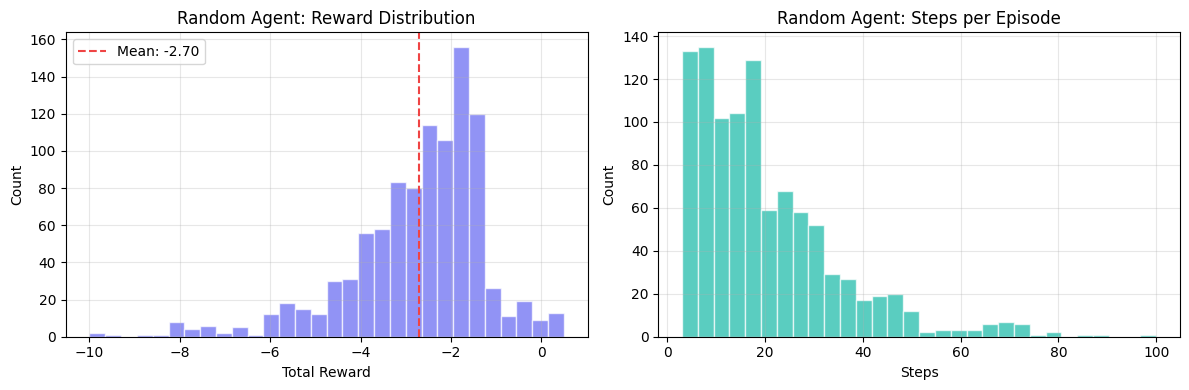

In [19]:
# Run 1000 episodes and collect rewards
n_episodes = 1000
rewards = []
steps_list = []

env = GridEnvironment()
agent = RandomAgent()

for _ in range(n_episodes):
    total_reward, steps, _ = run_episode(env, agent)
    rewards.append(total_reward)
    steps_list.append(steps)

print(f"Random Agent over {n_episodes} episodes:")
print(f"  Average reward: {np.mean(rewards):.3f} ± {np.std(rewards):.3f}")
print(f"  Average steps:  {np.mean(steps_list):.1f}")
print(f"  Goal reached:   {sum(1 for r in rewards if r > 0)}/{n_episodes}")

# Plot the reward distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rewards, bins=30, color='#6366f1', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Total Reward')
axes[0].set_ylabel('Count')
axes[0].set_title('Random Agent: Reward Distribution')
axes[0].axvline(np.mean(rewards), color='#ef4444', linestyle='--', label=f'Mean: {np.mean(rewards):.2f}')
axes[0].legend()

axes[1].hist(steps_list, bins=30, color='#14b8a6', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Count')
axes[1].set_title('Random Agent: Steps per Episode')
plt.tight_layout()
plt.show()

## 4. The Smart Agent: A Hand-Coded Policy

A **policy** is a mapping from states to actions: π(s) → a.

Before we learn a policy automatically, let's prove that a good policy *matters* by hand-coding one. Look at the grid:

```
 S → → ↓
 ↓  ■  ↓ X
 ↓  → → ↓
 X  .  . G
```

In [20]:
class ManualPolicyAgent:
    """
    An agent with a hand-coded policy for our 4x4 GridEnvironment.
    
    The policy is a dictionary mapping (row, col) -> action.
    """
    
    def __init__(self):
        # A safe path: go right along row 0, then down column 2, then right to goal
        self.policy = {
            (0, 0): 1,  # RIGHT
            (0, 1): 1,  # RIGHT
            (0, 2): 2,  # DOWN
            (0, 3): 2,  # DOWN (safety — avoid going into trap from above)
            (1, 0): 2,  # DOWN (avoid wall)
            (1, 2): 2,  # DOWN
            (2, 0): 1,  # RIGHT (move away from trap below)
            (2, 1): 1,  # RIGHT
            (2, 2): 2,  # DOWN
            (2, 3): 2,  # DOWN
            (3, 1): 1,  # RIGHT
            (3, 2): 1,  # RIGHT → goal!
        }
    
    def act(self, state):
        """Choose an action based on the hand-coded policy."""
        return self.policy.get(state, 1)  # Default: go RIGHT

Random Agent — Mean reward: -2.634
Smart Agent  — Mean reward: 0.500


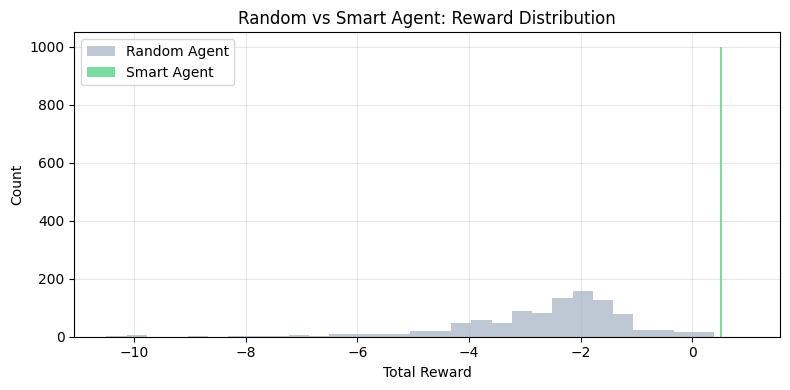

In [21]:
# Compare the two agents!
env = GridEnvironment()

random_agent = RandomAgent()
smart_agent = ManualPolicyAgent()

n_episodes = 1000
random_rewards = [run_episode(env, random_agent)[0] for _ in range(n_episodes)]
smart_rewards = [run_episode(env, smart_agent)[0] for _ in range(n_episodes)]

print(f"Random Agent — Mean reward: {np.mean(random_rewards):.3f}")
print(f"Smart Agent  — Mean reward: {np.mean(smart_rewards):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(random_rewards, bins=30, alpha=0.6, label='Random Agent', color='#94a3b8')
ax.hist(smart_rewards, bins=30, alpha=0.6, label='Smart Agent', color='#22c55e')
ax.set_xlabel('Total Reward')
ax.set_ylabel('Count')
ax.set_title('Random vs Smart Agent: Reward Distribution')
ax.legend()
plt.tight_layout()
plt.show()

### 💡 Key Insight

The smart agent crushes the random agent. This is the whole point of RL:

> **We just hand-coded the policy. RL's job is to *learn* it automatically.**

Before we can do that, we need to formalise the problem. Enter the MDP.

---

## 5. The Markov Decision Process (MDP)

An MDP is the mathematical framework that makes RL precise. It's a 5-tuple:

$$\text{MDP} = (\mathcal{S}, \mathcal{A}, P, R, \gamma)$$

| Symbol | Meaning | Our GridEnvironment Example |
|--------|---------|----------------------|
| $\mathcal{S}$ | **State space** — all possible situations | All 16 grid cells: (0,0), (0,1), ... (3,3) |
| $\mathcal{A}$ | **Action space** — all possible actions | {UP, RIGHT, DOWN, LEFT} = {0, 1, 2, 3} |
| $P(s'\|s, a)$ | **Transition function** — probability of landing in $s'$ after doing $a$ in $s$ | Deterministic in our grid (prob = 1.0) |
| $R(s, a, s')$ | **Reward function** — immediate reward for a transition | +1.0 (goal), -1.0 (trap), -0.1 (step) |
| $\gamma$ | **Discount factor** — how much we value future vs present rewards (0 to 1) | We'll explore this in Notebook 02 |

### The Markov Property

The "Markov" in MDP means: **the future depends only on the current state, not on the history**.

$$P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, \dots) = P(s_{t+1} | s_t, a_t)$$

In plain English: knowing where you are right now is enough to decide what happens next. You don't need to remember how you got here.

🤔 **Think about it**: Is chess Markov? Is poker? (Spoiler: chess yes, poker requires an expanded state definition — more in Notebook 15!)

### Building the Transition Table

A fully-specified MDP has a **transition table** P[s][a] that tells you exactly what happens for every state-action pair.

In [29]:
def build_transition_table(env):
    """
    Build the complete transition table P[s][a] = [(prob, next_state, reward, done)].
    
    We represent states as integers: state = row * cols + col
    """
    n_states = env.rows * env.cols
    n_actions = 4
    P = {}
    
    for s in range(n_states):
        P[s] = {}
        row, col = s // env.cols, s % env.cols
        
        for a in range(n_actions):
            # Terminal states: stay in place, no reward
            if (row, col) == env.goal or (row, col) in env.traps:
                P[s][a] = [(1.0, s, 0.0, True)]
                continue
            
            # Compute intended next position
            dr, dc = env.ACTION_DELTAS[a]
            new_row, new_col = row + dr, col + dc
            
            # Check bounds and walls
            if (new_row < 0 or new_row >= env.rows or
                new_col < 0 or new_col >= env.cols or
                (new_row, new_col) in env.walls):
                new_row, new_col = row, col  # Stay in place
            
            new_s = new_row * env.cols + new_col
            
            # Determine reward
            if (new_row, new_col) == env.goal:
                reward = env.goal_reward
                done = True
            elif (new_row, new_col) in env.traps:
                reward = env.trap_reward
                done = True
            else:
                reward = env.step_reward
                done = False
            
            P[s][a] = [(1.0, new_s, reward, done)]
    
    return P, n_states, n_actions

In [23]:
# Build and inspect the transition table
env = GridEnvironment()
P, n_states, n_actions = build_transition_table(env)

# Let's check a few entries
print("Transition table spot-checks:")
print(f"  State 0 (0,0), Action RIGHT: {P[0][1]}")
print(f"  State 1 (0,1), Action DOWN:  {P[1][2]}")
print(f"  State 5 (1,1=wall), Action RIGHT: {P[5][1]}")
print(f"  State 15 (3,3=goal), Action UP: {P[15][0]}")
print(f"\nTotal: {n_states} states × {n_actions} actions = {n_states * n_actions} entries")

Transition table spot-checks:
  State 0 (0,0), Action RIGHT: [(1.0, 1, -0.1, False)]
  State 1 (0,1), Action DOWN:  [(1.0, 1, -0.1, False)]
  State 5 (1,1=wall), Action RIGHT: [(1.0, 6, -0.1, False)]
  State 15 (3,3=goal), Action UP: [(1.0, 15, 0.0, True)]

Total: 16 states × 4 actions = 64 entries


## 6. Visualising the MDP

Let's render our transition dynamics as a grid of arrows and values.

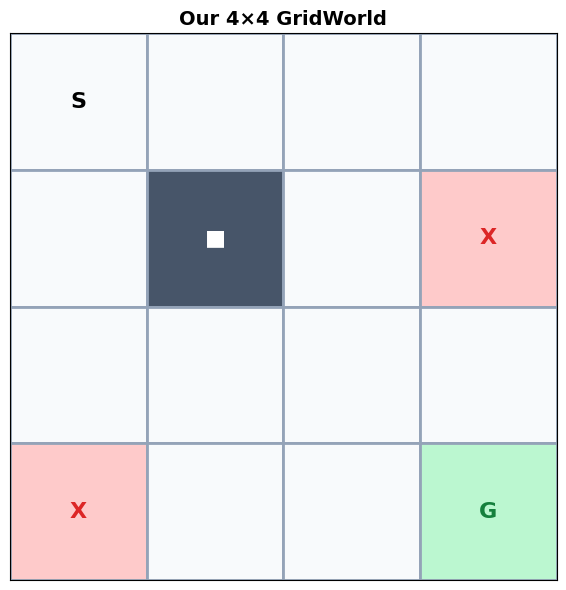

In [24]:
def visualize_gridworld(env, policy=None, title="GridEnvironment"):
    """
    Visualize the GridEnvironment with optional policy arrows.
    """
    fig, ax = plt.subplots(figsize=(env.cols * 1.5, env.rows * 1.5))
    
    # Draw grid
    for r in range(env.rows):
        for c in range(env.cols):
            color = '#f8fafc'  # default light
            if (r, c) == env.goal:
                color = '#bbf7d0'  # green
            elif (r, c) in env.traps:
                color = '#fecaca'  # red
            elif (r, c) in env.walls:
                color = '#475569'  # dark
            
            rect = plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                                  facecolor=color, edgecolor='#94a3b8', linewidth=2)
            ax.add_patch(rect)
            
            # Labels
            if (r, c) == env.start:
                ax.text(c + 0.5, env.rows - 1 - r + 0.5, 'S',
                       ha='center', va='center', fontsize=16, fontweight='bold')
            elif (r, c) == env.goal:
                ax.text(c + 0.5, env.rows - 1 - r + 0.5, 'G',
                       ha='center', va='center', fontsize=16, fontweight='bold', color='#15803d')
            elif (r, c) in env.traps:
                ax.text(c + 0.5, env.rows - 1 - r + 0.5, 'X',
                       ha='center', va='center', fontsize=16, fontweight='bold', color='#dc2626')
            elif (r, c) in env.walls:
                ax.text(c + 0.5, env.rows - 1 - r + 0.5, '■',
                       ha='center', va='center', fontsize=16, color='white')
    
    # Draw policy arrows
    if policy is not None:
        arrow_map = {0: (0, 0.25), 1: (0.25, 0), 2: (0, -0.25), 3: (-0.25, 0)}
        for (r, c), action in policy.items():
            if (r, c) not in env.walls and (r, c) != env.goal and (r, c) not in env.traps:
                dx, dy = arrow_map[action]
                ax.annotate('', xy=(c + 0.5 + dx, env.rows - 1 - r + 0.5 + dy),
                           xytext=(c + 0.5, env.rows - 1 - r + 0.5),
                           arrowprops=dict(arrowstyle='->', color='#6366f1', lw=2.5))
    
    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

# Visualize the grid
env = GridEnvironment()
visualize_gridworld(env, title="Our 4×4 GridEnvironment")

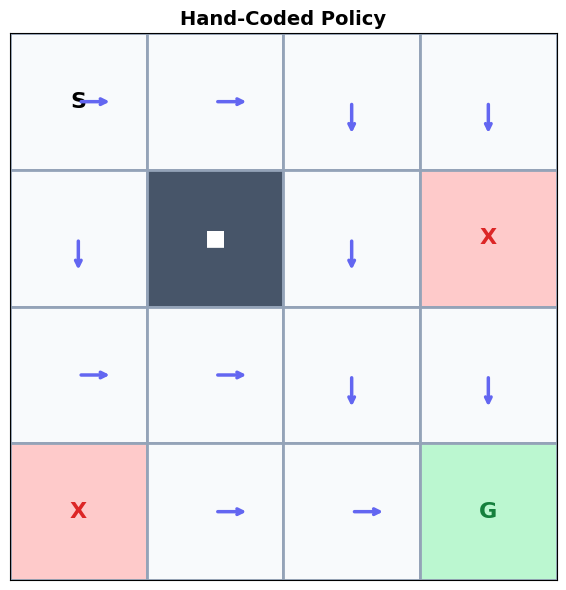

In [25]:
# Visualize with the hand-coded policy
smart = ManualPolicyAgent()
visualize_gridworld(env, policy=smart.policy, title="Hand-Coded Policy")

## 7. The Policy: Deterministic vs Stochastic

Our hand-coded policy is **deterministic**: for each state, there's exactly one action.

$$\pi(s) = a \quad \text{(deterministic)}$$

But policies can also be **stochastic**: for each state, there's a *probability distribution* over actions.

$$\pi(a|s) = P(A_t = a | S_t = s) \quad \text{(stochastic)}$$

The random agent is a stochastic policy with:
$$\pi(a|s) = \frac{1}{|\mathcal{A}|} = 0.25 \quad \forall s, a$$

In [26]:
class StochasticPolicyAgent:
    """
    An agent with a stochastic policy.
    
    The policy is a dictionary mapping state -> probability array over actions.
    """
    
    def __init__(self, n_actions=4):
        self.n_actions = n_actions
        # Default: uniform random
        self.policy = defaultdict(lambda: np.ones(n_actions) / n_actions)
    
    def set_preference(self, state, action, prob):
        """Set a higher probability for a specific action in a state.
        Remaining probability is split equally among other actions."""
        probs = np.ones(self.n_actions) * (1 - prob) / (self.n_actions - 1)
        probs[action] = prob
        self.policy[state] = probs
    
    def act(self, state):
        """Sample an action from the policy distribution for this state."""
        return np.random.choice(self.n_actions, p=self.policy[state])

In [27]:
# Create a "mostly smart" stochastic agent
# 80% chance of the good action, 20% split among others
stoch_agent = StochasticPolicyAgent()
stoch_agent.set_preference((0, 0), 1, 0.8)  # (0,0): mostly go RIGHT
stoch_agent.set_preference((0, 1), 1, 0.8)  # (0,1): mostly go RIGHT
stoch_agent.set_preference((0, 2), 2, 0.8)  # (0,2): mostly go DOWN
stoch_agent.set_preference((1, 2), 2, 0.8)  # (1,2): mostly go DOWN
stoch_agent.set_preference((2, 2), 2, 0.8)  # (2,2): mostly go DOWN
stoch_agent.set_preference((3, 2), 1, 0.8)  # (3,2): mostly go RIGHT

# Compare all three
stoch_rewards = [run_episode(env, stoch_agent)[0] for _ in range(n_episodes)]

print("Comparison over 1000 episodes:")
print(f"  Random agent:     {np.mean(random_rewards):.3f} ± {np.std(random_rewards):.3f}")
print(f"  Stochastic agent: {np.mean(stoch_rewards):.3f} ± {np.std(stoch_rewards):.3f}")
print(f"  Deterministic:    {np.mean(smart_rewards):.3f} ± {np.std(smart_rewards):.3f}")

Comparison over 1000 episodes:
  Random agent:     -2.634 ± 1.536
  Stochastic agent: -0.166 ± 0.871
  Deterministic:    0.500 ± 0.000


## 8. Making Things Interesting: Stochastic Environments

So far, our environment is **deterministic** — action RIGHT always moves right. But real-world environments are noisy. What if there's a 10% chance of slipping to a random direction?

This changes the transition function from:
$$P(s'|s,a) = \begin{cases} 1.0 & \text{if } s' = \text{intended next state} \end{cases}$$

To:
$$P(s'|s,a) = \begin{cases} 0.9 + 0.1/4 = 0.925 & \text{if } s' = \text{intended} \\ 0.1/4 = 0.025 & \text{for each other direction} \end{cases}$$

In [28]:
# We can use the GridEnvironment from utils/ which supports stochasticity
import sys
sys.path.insert(0, '..')  # Add parent dir for imports

from utils.envs import GridEnvironment

# Deterministic version
env_det = GridEnvironment(rows=4, cols=4, walls=[(1,1)], traps=[(1,3), (3,0)], stochastic=False)

# Stochastic version (10% slip)
env_stoch = GridEnvironment(rows=4, cols=4, walls=[(1,1)], traps=[(1,3), (3,0)],
                      stochastic=True, slip_prob=0.1)

# Compare using the same smart policy
class SmartAgentInt:
    """Wrapper that converts integer states to (row,col) for our manual policy."""
    def __init__(self, policy_dict, cols=4):
        self.policy_dict = policy_dict
        self.cols = cols
    def act(self, state):
        r, c = state // self.cols, state % self.cols
        return self.policy_dict.get((r, c), 1)

smart_int = SmartAgentInt(smart.policy)

def run_episode_int(env, agent, max_steps=100):
    """Run episode with integer-state environment."""
    state = env.reset()
    total_reward = 0
    for step in range(max_steps):
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        state = next_state
        if done:
            break
    return total_reward

det_rewards = [run_episode_int(env_det, smart_int) for _ in range(1000)]
stoch_rewards_env = [run_episode_int(env_stoch, smart_int) for _ in range(1000)]

print(f"Deterministic environment: {np.mean(det_rewards):.3f} ± {np.std(det_rewards):.3f}")
print(f"Stochastic environment:    {np.mean(stoch_rewards_env):.3f} ± {np.std(stoch_rewards_env):.3f}")
print(f"\n→ Noise hurts! The same policy performs worse in a slippery world.")

Deterministic environment: 0.500 ± 0.000
Stochastic environment:    0.339 ± 0.428

→ Noise hurts! The same policy performs worse in a slippery world.


## 9. Recap & Key Takeaways

### What we built:
- ✅ A **GridEnvironment environment** with step(), reset(), and render()
- ✅ A **random agent** (baseline)
- ✅ A **hand-coded policy agent** (upper baseline)
- ✅ A **stochastic policy agent** (middle ground)
- ✅ The **MDP transition table** P[s][a]

### Key vocabulary:

| Term | Definition |
|------|------------|
| **Agent** | The decision-maker |
| **Environment** | Everything outside the agent |
| **State** $s$ | The current situation |
| **Action** $a$ | What the agent does |
| **Reward** $r$ | Immediate feedback signal |
| **Policy** $\pi$ | The agent's strategy (state → action) |
| **MDP** | $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$ — the formal problem |
| **Episode** | One complete run from start to terminal state |
| **Markov Property** | The future depends only on the present state |

### The big question we haven't answered:

> We hand-coded the policy. But **how do we measure which policy is best?** How do we quantify "future reward"?

That's the **Bellman Equation** — the subject of **Notebook 02: Time Travel**.

---

## 🧪 Exercises (Optional Challenges)

1. **Bigger grid**: Make a 6×6 grid with more walls and traps. Does the random agent do even worse?

2. **Step limit**: What happens if you reduce `max_steps` to 20? Which agent is affected more?

3. **Slippery world**: Set `slip_prob=0.3`. Can you design a hand-coded policy that still works well? (Hint: you might want to avoid walking along trap-adjacent cells.)

4. **Non-Markov challenge**: Think of a real-world situation that violates the Markov property. How would you modify the state to make it Markov? (Hint: think of a card game where history matters.)

---

*Next up: [Notebook 02 — Time Travel: Returns and the Bellman Equation](02_returns_bellman.ipynb)*